В блокноте попытка дообучить модель из предыдущего блокнота (2_2_ArcFace.ipynb) еще на 10 эпох. Тут немножко увеличены вероятности аугментаций, в A.ImageCompression расширен диапазон качества и добавлена A.GaussNoise.

In [1]:
!pip install albumentationsx

In [2]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision.datasets import ImageFolder
import torchvision.models as models

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

from tqdm import tqdm


In [3]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [4]:
root_dir = '/content/gdrive/MyDrive/Colab Notebooks/fr/'
checkpoint_dir = root_dir + 'checkpoints/ArcFace/'
data_dir = 'aligned/'

In [5]:
os.makedirs(checkpoint_dir, exist_ok=True)

In [6]:
!unzip -q '/content/gdrive/MyDrive/Colab Notebooks/fr/aligned.zip'

Создание классов для датасетов.

In [7]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.HorizontalFlip(p=0.2),
    A.Affine(
        translate_percent={"x": (-0.02, 0.02), "y": (-0.02, 0.02)},
        scale=(0.95, 1.05),
        rotate=(-3, 3),
        balanced_scale=True, p=0.5),
    A.CoarseDropout(
        num_holes_range=(1, 3),
        hole_height_range=(10, 40),
        hole_width_range=(10, 40),
        p=0.3),
    A.ToGray(p=0.2),
    A.OneOf([
        A.RandomBrightnessContrast(p=1.0),
        A.RandomGamma(p=1.0),
    ], p=0.4),
    A.OneOf([
        A.MotionBlur(p=1.0),
        A.GaussianBlur(p=1.0),
        A.ImageCompression(quality_range=(60, 100), p=1.0),
        A.GaussNoise(p=1.0),
    ], p=0.3),
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])


In [8]:
def opencv_loader(path: str) -> np.ndarray:
    """Загружает изображение с помощью OpenCV в формате RGB для Albumentations."""
    img = cv2.imread(path)
    # По умолчанию cv2 читает в BGR, поэтому переводим в RGB
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


class AlbumentationsDataset(Dataset):
    def __init__(self, image_folder, transform=None):
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.image_folder)

    def __getitem__(self, idx):
        # Получаем изображение и метку из ImageFolder
        image, label = self.image_folder[idx]

        # Если transform передан, применяем его
        if self.transform:
            image = self.transform(image=image)['image']

        return image, label


In [9]:
BATCH_SIZE = 128

train_dataset = AlbumentationsDataset(ImageFolder(root=f'{data_dir}train/', loader=opencv_loader), transform=train_transform)
val_dataset = AlbumentationsDataset(ImageFolder(root=f'{data_dir}val/', loader=opencv_loader), transform=test_transform)
test_dataset = AlbumentationsDataset(ImageFolder(root=f'{data_dir}test/', loader=opencv_loader), transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [10]:
print(train_dataset.image_folder.classes)
print(train_dataset.image_folder.class_to_idx)

['10001', '10003', '10006', '10014', '10023', '10025', '10029', '1003', '10032', '10036', '10042', '10044', '10047', '10050', '10059', '10060', '10077', '1008', '10083', '10086', '10089', '10093', '10102', '10108', '10111', '10132', '10134', '1014', '10144', '10149', '10156', '10157', '10160', '10174', '10175', '1034', '1035', '1044', '1054', '1059', '1088', '1089', '1113', '1136', '1137', '114', '1154', '1170', '1175', '1180', '1181', '1187', '1194', '1198', '1210', '122', '1224', '1228', '1231', '1245', '1258', '1272', '1279', '1287', '1288', '1303', '1305', '1318', '1321', '1322', '1324', '1330', '1336', '1337', '1348', '1351', '1361', '1362', '1370', '1373', '1382', '1384', '1393', '1395', '14', '1410', '1411', '142', '1423', '1435', '1439', '1440', '1443', '1446', '1447', '1448', '1454', '1455', '1468', '147', '1472', '1474', '1481', '1489', '1490', '1493', '1496', '1519', '1538', '1544', '1549', '1550', '1569', '1578', '1581', '1588', '1601', '1603', '1604', '1614', '1634', '1639

Обучение модели.

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [12]:
class ArcFace(nn.Module):
    def __init__(self, in_features, num_classes, s=64.0, m=0.5):
        super().__init__()
        self.num_classes = num_classes
        self.s = s
        self.m = m
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels=None):
        embeddings = F.normalize(embeddings)
        W = F.normalize(self.weight)

        cosine = F.linear(embeddings, W)

        if labels is not None:
            sine = torch.sqrt(1.0 - torch.pow(cosine, 2).clamp(0, 1))

            phi = cosine * self.cos_m - sine * self.sin_m
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)

            one_hot = F.one_hot(labels, num_classes=self.num_classes).float()
            output = (one_hot * phi) + ((1.0 - one_hot) * cosine)

        else:
            output = cosine

        output *= self.s
        return output


class ResNet18ArcFace(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet18(weights='DEFAULT')
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.arcface = ArcFace(in_features, num_classes)

    def forward(self, x, labels=None):
        embeddings = self.backbone(x)
        output = self.arcface(embeddings, labels)
        return output


In [13]:
model = ResNet18ArcFace(num_classes=1000)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 127MB/s]


In [14]:
sum([len(p.ravel()) for p in model.parameters()])

11688512

In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
criterion = nn.CrossEntropyLoss()

In [16]:
train_loss_list = []
train_accuracy_list = []

val_loss_list = []
val_accuracy_list = []

# значения на 20, 30 и 40 эпохах из предыдущего файла (2_2_ArcFace.ipynb)
train_loss_without_m_list = [0.3739401824474335, 0.17839966700722773, 0.1387421938975652]
train_accuracy_without_m_list = [0.9547083333333334, 0.97675, 0.9815416666666666]


In [17]:
def fit_one_epoch(model, loader, criterion, optimizer):
    total_loss = 0.0
    correct_preds = 0.0
    total_samples = 0.0

    model.train()
    for batch_x, batch_y in tqdm(loader):
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_x, batch_y)
        loss = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)
        preds = logits.argmax(-1)
        correct_preds += (preds == batch_y).sum().item()
        total_samples += batch_x.size(0)

    mean_loss = total_loss / total_samples
    accuracy = correct_preds / total_samples

    return mean_loss, accuracy


def eval_one_epoch(model, loader, criterion):
    total_loss = 0.0
    correct_preds = 0.0
    total_samples = 0.0

    model.eval()
    with torch.no_grad():
        for batch_x, batch_y in tqdm(loader):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            total_loss += loss.item() * batch_x.size(0)
            preds = logits.argmax(-1)
            correct_preds += (preds == batch_y).sum().item()
            total_samples += batch_x.size(0)

    mean_loss = total_loss / total_samples
    accuracy = correct_preds / total_samples

    return mean_loss, accuracy


def train(start=0):
    best_val_accuracy = max(val_accuracy_list, default=0)

    for epoch in range(start, start + epochs):
        print(f"\nEpoch [{epoch + 1}/{start + epochs}]")

        train_loss, train_accuracy = fit_one_epoch(model, train_loader, criterion, optimizer)
        train_loss_list.append(train_loss)
        train_accuracy_list.append(train_accuracy)
        print(f"train_loss={train_loss:.4f}, train_accuracy={train_accuracy:.4f}")

        val_loss, val_accuracy = eval_one_epoch(model, val_loader, criterion)
        val_loss_list.append(val_loss)
        val_accuracy_list.append(val_accuracy)
        print(f"val_loss={val_loss:.4f}, val_accuracy={val_accuracy:.4f}")

        train_loss_without_m, train_accuracy_without_m = eval_one_epoch(model, train_loader, criterion)
        train_loss_without_m_list.append(train_loss_without_m)
        train_accuracy_without_m_list.append(train_accuracy_without_m)
        print(f"train_loss_without_m={train_loss_without_m:.4f}, train_accuracy_without_m={train_accuracy_without_m:.4f}")

        scheduler.step()

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.backbone.state_dict(), f'{checkpoint_dir}epoch_{epoch + 1}_best_val_accuracy.pth')

        if (epoch + 1) % 5 == 0:
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss_list': train_loss_list,
                'train_accuracy_list': train_accuracy_list,
                'val_loss_list': val_loss_list,
                'val_accuracy_list': val_accuracy_list,
            }, f'{checkpoint_dir}epoch_{epoch + 1}.pth')


Загружаем данные 40 эпохи.

In [18]:
checkpoint = torch.load(f'{checkpoint_dir}epoch_40.pth')

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
train_loss_list = checkpoint['train_loss_list']
train_accuracy_list = checkpoint['train_accuracy_list']
val_loss_list = checkpoint['val_loss_list']
val_accuracy_list = checkpoint['val_accuracy_list']


Обучение на 10 эпох.

In [19]:
epochs = 10

In [20]:
train(start=40)


Epoch [41/50]


100%|██████████| 188/188 [02:08<00:00,  1.46it/s]


train_loss=6.6389, train_accuracy=0.6457


100%|██████████| 24/24 [00:08<00:00,  2.96it/s]


val_loss=1.0716, val_accuracy=0.8693


...

train_loss=5.8382, train_accuracy=0.6824


100%|██████████| 24/24 [00:08<00:00,  2.98it/s]


val_loss=1.0445, val_accuracy=0.8747


100%|██████████| 188/188 [01:25<00:00,  2.19it/s]


train_loss_without_m=0.5084, train_accuracy_without_m=0.9183


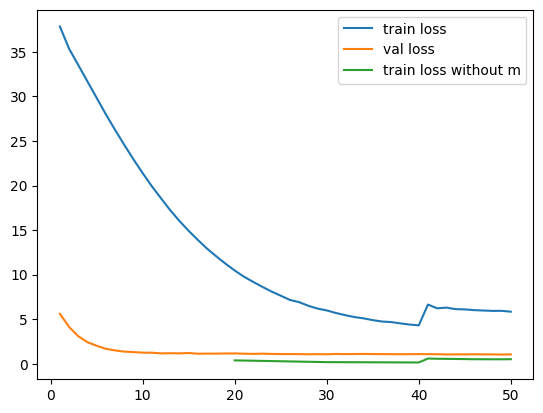

In [21]:
plt.plot(range(1, 51), train_loss_list, label='train loss')
plt.plot(range(1, 51), val_loss_list, label='val loss')
plt.plot([20, 30, *range(40, 51)], train_loss_without_m_list, label='train loss without m')
plt.legend()
plt.show()

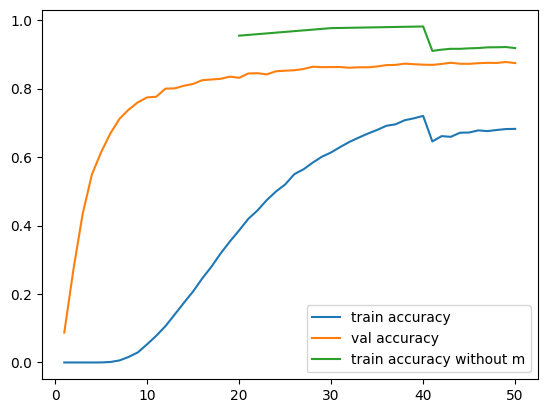

In [22]:
plt.plot(range(1, 51), train_accuracy_list, label='train accuracy')
plt.plot(range(1, 51), val_accuracy_list, label='val accuracy')
plt.plot([20, 30, *range(40, 51)], train_accuracy_without_m_list, label='train accuracy without m')
plt.legend()
plt.show()

Посмотрим лосс и accuracy на тесте.

In [23]:
test_loss, test_accuracy = eval_one_epoch(model, test_loader, criterion)
test_loss, test_accuracy

100%|██████████| 24/24 [00:07<00:00,  3.10it/s]


(0.9797249968846639, 0.8856666666666667)

Ступеньки в графиках это из-за большего числа аугментаций. Лучшее чиселко val_accuracy=0.8777.